# MolAlign 数据集探索与可视化

MolAlign — 分子跨模态对齐数据集 (Sci-Align)

本 Notebook 展示数据集的基本统计信息、类别分布、属性分布和分子结构示例。

In [ ]:
import json
import os
from pathlib import Path

# Robust path resolution: works from notebooks/ or project root
_project_root = Path(globals().get('_dh', [Path.cwd()])[0]).resolve()
if not (_project_root / 'data').exists() and (_project_root.parent / 'data').exists():
    _project_root = _project_root.parent
dataset_path = _project_root / 'data' / 'processed' / 'molalign_dataset.jsonl'

records = []
with open(dataset_path, 'r', encoding='utf-8') as f:
    for line in f:
        if line.strip():
            records.append(json.loads(line))

print(f'Dataset: {len(records)} records loaded from {dataset_path}')
print(f'First record: {records[0]["names"]["common_name"]} ({records[0]["record_id"]})')

## 1. 数据集概览

In [2]:
import pandas as pd

df = pd.DataFrame([{
    'record_id': r['record_id'],
    'name': r['names']['common_name'],
    'category': r.get('category', 'Unknown'),
    'smiles': r['smiles']['canonical'],
    'mw': r['properties']['physicochemical']['molecular_weight'],
    'logp': r['properties']['physicochemical']['logp'],
    'tpsa': r['properties']['physicochemical']['tpsa'],
    'hbd': r['properties']['physicochemical']['hydrogen_bond_donors'],
    'hba': r['properties']['physicochemical']['hydrogen_bond_acceptors'],
    'n_descriptions': len(r['text_descriptions']),
    'n_relations': len(r['entity_relations']),
    'has_2d': r['modalities']['structure_2d'].get('rdkit_generated') is not None,
    'has_3d': r['modalities']['structure_3d'].get('sdf_path') is not None,
    'n_mineru': len(r['alignment_metadata']['mineru_usage']),
    'has_zh': any(d.get('language') == 'zh' for d in r['text_descriptions']),
} for r in records])

print(df.describe().round(2))

            mw    logp     tpsa     hbd     hba  n_descriptions  n_relations  \
count   120.00  116.00   120.00  120.00  120.00          120.00       120.00   
mean    423.92    1.98   112.11    3.12    6.48            1.96         1.88   
std     540.05    2.71   219.80    7.90    8.95            0.35         0.64   
min     103.12  -10.80     2.00    0.00    1.00            1.00         1.00   
25%     266.77    0.38    46.28    1.00    3.00            2.00         1.75   
50%     335.40    2.35    80.20    2.00    5.00            2.00         2.00   
75%     434.00    3.62   106.25    3.00    7.00            2.00         2.00   
max    5814.00   10.30  2310.00   84.00   89.00            3.00         4.00   

       n_mineru  
count     120.0  
mean        2.0  
std         0.0  
min         2.0  
25%         2.0  
50%         2.0  
75%         2.0  
max         2.0  


## 2. 类别分布

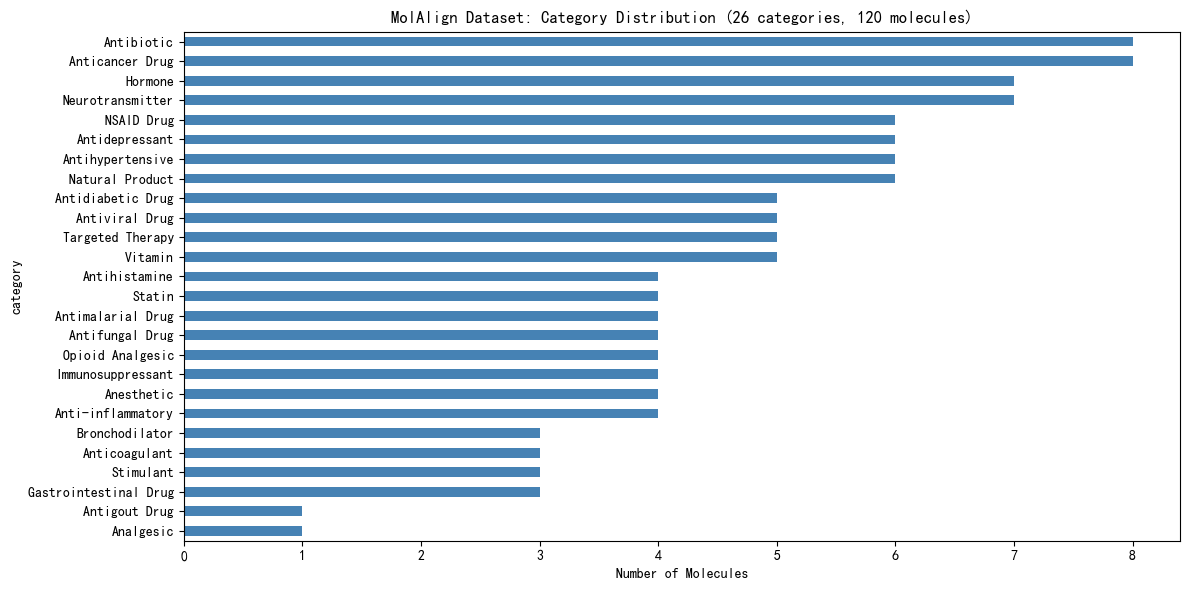

Total categories: 26


In [3]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS']
matplotlib.rcParams['axes.unicode_minus'] = False

cat_counts = df['category'].value_counts()

fig, ax = plt.subplots(figsize=(12, 6))
cat_counts.plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Number of Molecules')
ax.set_title('MolAlign Dataset: Category Distribution (26 categories, 120 molecules)')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('../docs/figures/category_distribution.png', dpi=150)
plt.show()
print(f'Total categories: {len(cat_counts)}')

## 3. 分子属性分布

C:\Users\cacin\AppData\Local\Temp\claude\ipykernel_26176\3406757578.py:28: UserWarning: Glyph 197 (\N{LATIN CAPITAL LETTER A WITH RING ABOVE}) missing from font(s) SimHei.
  plt.tight_layout()
C:\Users\cacin\AppData\Local\Temp\claude\ipykernel_26176\3406757578.py:28: UserWarning: Glyph 178 (\N{SUPERSCRIPT TWO}) missing from font(s) SimHei.
  plt.tight_layout()
C:\Users\cacin\AppData\Local\Temp\claude\ipykernel_26176\3406757578.py:29: UserWarning: Glyph 197 (\N{LATIN CAPITAL LETTER A WITH RING ABOVE}) missing from font(s) SimHei.
  plt.savefig('../docs/figures/property_distributions.png', dpi=150)
C:\Users\cacin\AppData\Local\Temp\claude\ipykernel_26176\3406757578.py:29: UserWarning: Glyph 178 (\N{SUPERSCRIPT TWO}) missing from font(s) SimHei.
  plt.savefig('../docs/figures/property_distributions.png', dpi=150)


C:\Users\cacin\miniconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 197 (\N{LATIN CAPITAL LETTER A WITH RING ABOVE}) missing from font(s) SimHei.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\cacin\miniconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 178 (\N{SUPERSCRIPT TWO}) missing from font(s) SimHei.
  fig.canvas.print_figure(bytes_io, **kw)


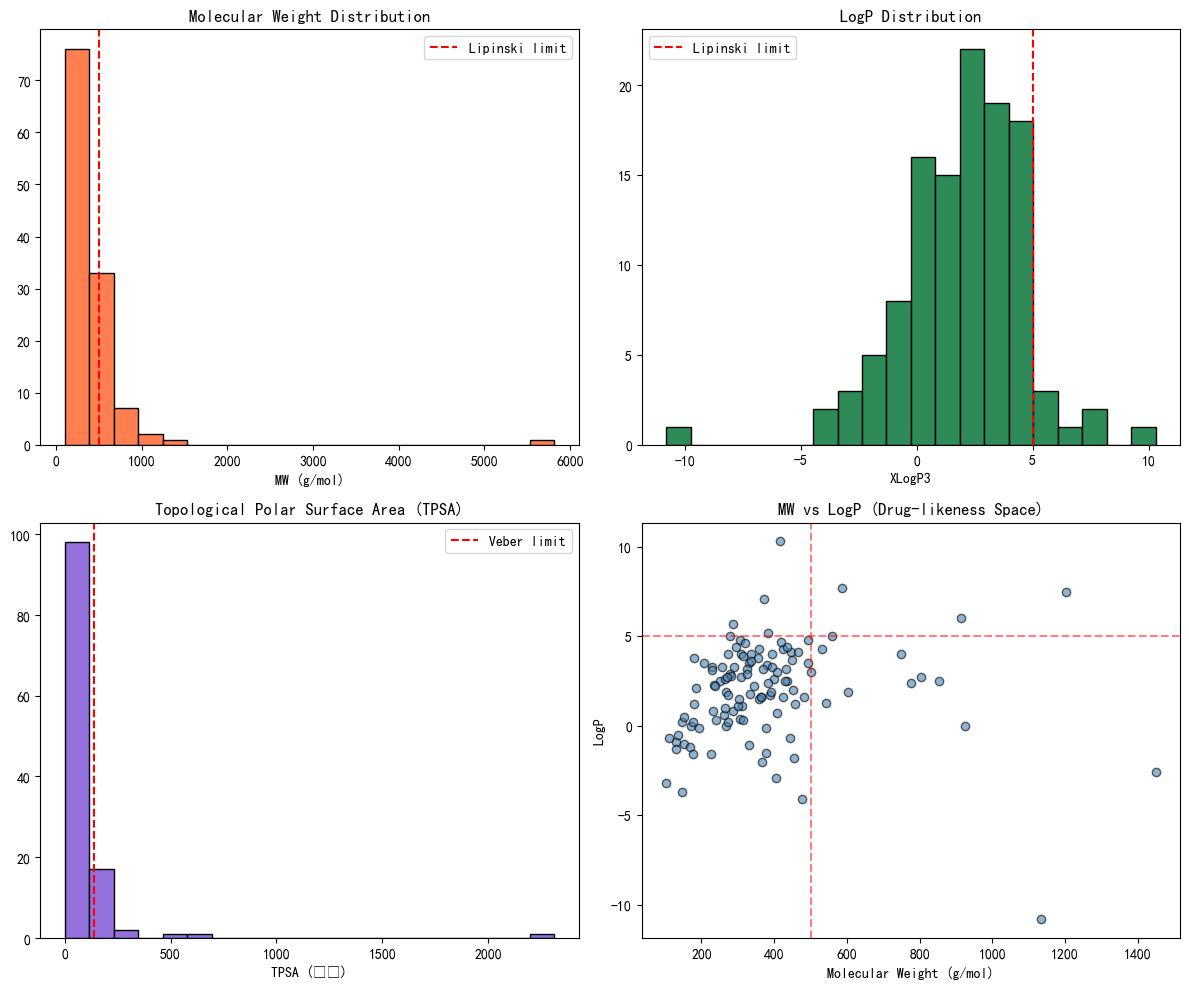

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0,0].hist(df['mw'].dropna(), bins=20, color='coral', edgecolor='black')
axes[0,0].set_title('Molecular Weight Distribution')
axes[0,0].set_xlabel('MW (g/mol)')
axes[0,0].axvline(x=500, color='red', linestyle='--', label='Lipinski limit')
axes[0,0].legend()

axes[0,1].hist(df['logp'].dropna(), bins=20, color='seagreen', edgecolor='black')
axes[0,1].set_title('LogP Distribution')
axes[0,1].set_xlabel('XLogP3')
axes[0,1].axvline(x=5, color='red', linestyle='--', label='Lipinski limit')
axes[0,1].legend()

axes[1,0].hist(df['tpsa'].dropna(), bins=20, color='mediumpurple', edgecolor='black')
axes[1,0].set_title('Topological Polar Surface Area (TPSA)')
axes[1,0].set_xlabel('TPSA (Å²)')
axes[1,0].axvline(x=140, color='red', linestyle='--', label='Veber limit')
axes[1,0].legend()

axes[1,1].scatter(df['mw'], df['logp'], alpha=0.6, c='steelblue', edgecolors='black')
axes[1,1].set_title('MW vs LogP (Drug-likeness Space)')
axes[1,1].set_xlabel('Molecular Weight (g/mol)')
axes[1,1].set_ylabel('LogP')
axes[1,1].axhline(y=5, color='red', linestyle='--', alpha=0.5)
axes[1,1].axvline(x=500, color='red', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('../docs/figures/property_distributions.png', dpi=150)
plt.show()

## 4. 跨模态对齐完整性

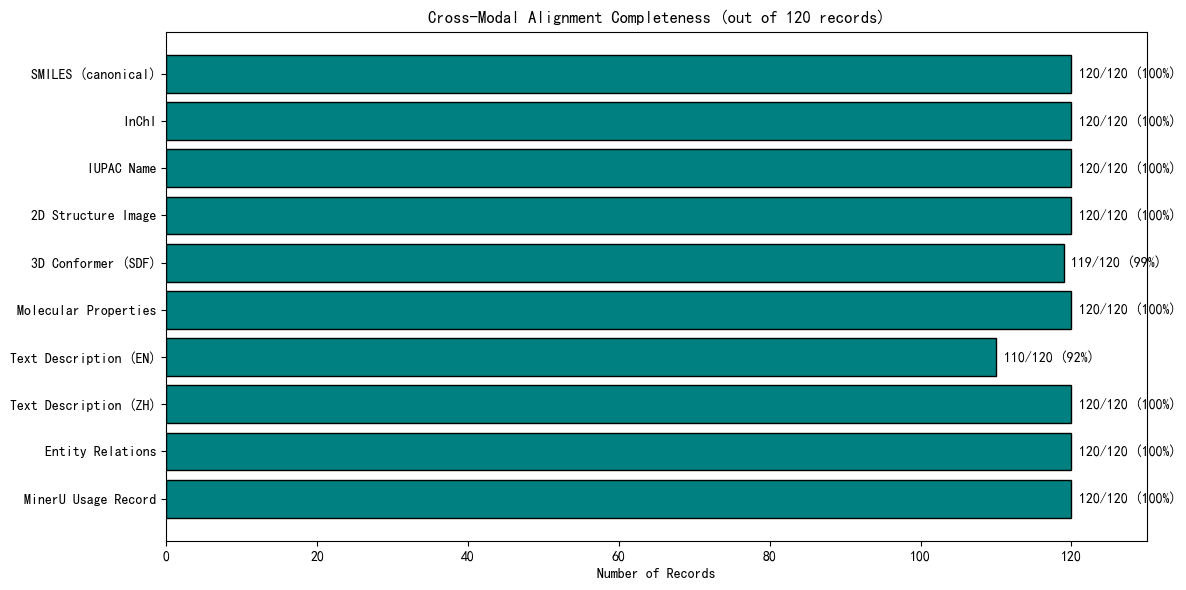

In [5]:
modality_stats = {
    'SMILES (canonical)': sum(1 for r in records if r['smiles']['canonical']),
    'InChI': sum(1 for r in records if r['smiles']['inchi']),
    'IUPAC Name': sum(1 for r in records if r['names'].get('iupac_name')),
    '2D Structure Image': sum(1 for r in records if r['modalities']['structure_2d'].get('rdkit_generated')),
    '3D Conformer (SDF)': sum(1 for r in records if r['modalities']['structure_3d'].get('sdf_path')),
    'Molecular Properties': sum(1 for r in records if r['properties']['physicochemical']['molecular_weight']),
    'Text Description (EN)': sum(1 for r in records if any(d.get('language')=='en' for d in r['text_descriptions'])),
    'Text Description (ZH)': sum(1 for r in records if any(d.get('language')=='zh' for d in r['text_descriptions'])),
    'Entity Relations': sum(1 for r in records if r['entity_relations']),
    'MinerU Usage Record': sum(1 for r in records if r['alignment_metadata']['mineru_usage']),
}

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(list(modality_stats.keys()), list(modality_stats.values()), color='teal', edgecolor='black')
ax.set_xlabel('Number of Records')
ax.set_title('Cross-Modal Alignment Completeness (out of 120 records)')
ax.set_xlim(0, 130)
ax.invert_yaxis()
for bar, val in zip(bars, modality_stats.values()):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2, f'{val}/120 ({val/120*100:.0f}%)', va='center')
plt.tight_layout()
plt.savefig('../docs/figures/modality_completeness.png', dpi=150)
plt.show()

## 5. 分子结构网格展示

Molecule grid saved to docs/figures/molecule_grid.png


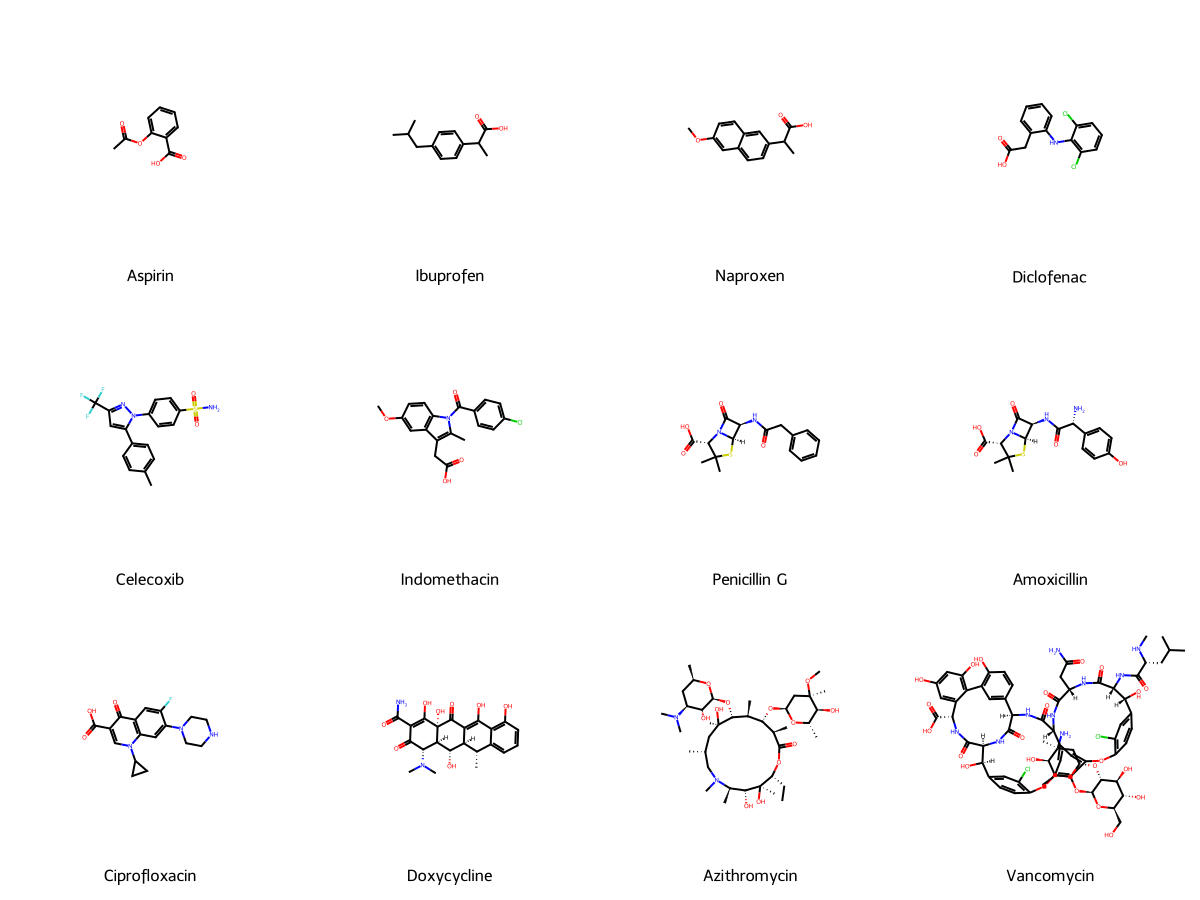

In [6]:
from rdkit import Chem
from rdkit.Chem import Draw
import matplotlib.image as mpimg

# Show 12 representative molecules
show_records = records[:12]
mols = []
labels = []
for r in show_records:
    mol = Chem.MolFromSmiles(r['smiles']['canonical'])
    if mol:
        mols.append(mol)
        labels.append(f"{r['names']['common_name']}")

img = Draw.MolsToGridImage(mols, molsPerRow=4, subImgSize=(300, 300), legends=labels)

# Save - handle both PIL Image and raw bytes
import os
os.makedirs('../docs/figures', exist_ok=True)
try:
    img.save('../docs/figures/molecule_grid.png')
except AttributeError:
    # RDKit returns bytes in some versions
    with open('../docs/figures/molecule_grid.png', 'wb') as f:
        f.write(img.data if hasattr(img, 'data') else img)

print('Molecule grid saved to docs/figures/molecule_grid.png')
from IPython.display import display, Image as IPImage
display(IPImage(filename='../docs/figures/molecule_grid.png'))

## 6. 实体关系统计

In [7]:
from collections import Counter

all_relations = []
for r in records:
    for rel in r['entity_relations']:
        all_relations.append(rel['relation'])

rel_counts = Counter(all_relations)
print('Entity Relation Types:')
for rel_type, count in rel_counts.most_common():
    print(f'  {rel_type}: {count}')

print(f'\nTotal relations: {len(all_relations)}')
print(f'Unique relation types: {len(rel_counts)}')
print(f'Avg relations/record: {len(all_relations)/len(records):.1f}')

Entity Relation Types:
  has_substructure: 77
  inhibits: 52
  derivative_of: 48
  binds_to: 33
  metabolized_to: 7
  activates: 2
  synthesized_from: 2
  co-administered_with: 1
  stabilizes: 1
  intercalates: 1
  generates: 1
  cofactor_of: 1

Total relations: 226
Unique relation types: 12
Avg relations/record: 1.9


## 7. Lipinski Rule-of-5 Analysis

In [8]:
violations = df['mw'].apply(lambda x: x > 500).astype(int) + \
             df['logp'].apply(lambda x: x > 5 if x else False).astype(int) + \
             df['hbd'].apply(lambda x: x > 5 if x else False).astype(int) + \
             df['hba'].apply(lambda x: x > 10 if x else False).astype(int)

vio_counts = violations.value_counts().sort_index()
print('Lipinski Rule-of-5 Violations:')
for n_vio, count in vio_counts.items():
    pct = count/len(df)*100
    print(f'  {n_vio} violations: {count} molecules ({pct:.1f}%)')

print(f'\nDrug-like (0-1 violations): {(violations <= 1).sum()} ({(violations <= 1).mean()*100:.1f}%)')

Lipinski Rule-of-5 Violations:
  0 violations: 95 molecules (79.2%)
  1 violations: 11 molecules (9.2%)
  2 violations: 7 molecules (5.8%)
  3 violations: 7 molecules (5.8%)

Drug-like (0-1 violations): 106 (88.3%)
